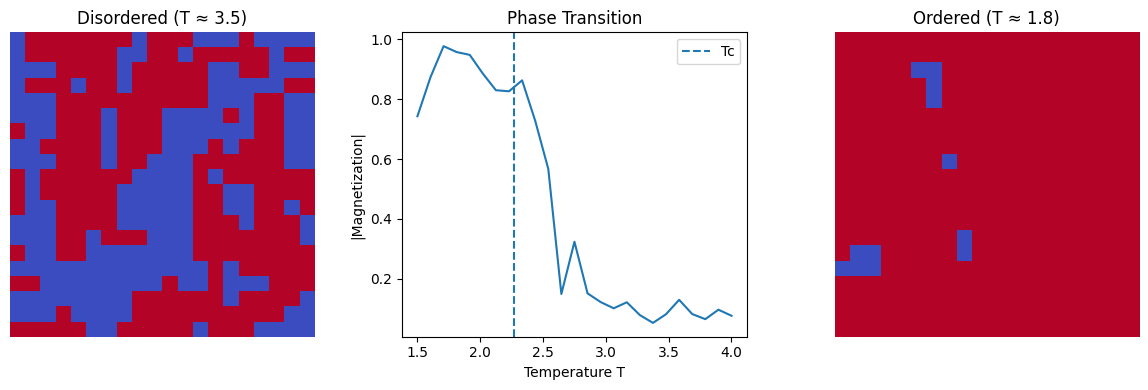

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
L = 20              # lattice size (L x L)
n_steps = 5000         # Monte Carlo steps per temperature
T_vals = np.linspace(1.5, 4.0, 25)  # temperature range
Tc = 2.269             # known critical temperature for 2D Ising

# temperatures for snapshots
T_low = 1.8
T_high = 3.5

# -----------------------------
# INITIALIZATION
# -----------------------------
def initialize_lattice(L):
    return np.random.choice([-1, 1], size=(L, L))

def energy(lattice):
    E = 0
    for i in range(L):
        for j in range(L):
            S = lattice[i, j]
            neighbors = (
                lattice[(i+1)%L, j] +
                lattice[(i-1)%L, j] +
                lattice[i, (j+1)%L] +
                lattice[i, (j-1)%L]
            )
            E += -S * neighbors
    return E / 2

def magnetization(lattice):
    return np.abs(np.sum(lattice)) / (L*L)

# -----------------------------
# METROPOLIS STEP
# -----------------------------
def metropolis_step(lattice, T):
    i = np.random.randint(0, L)
    j = np.random.randint(0, L)

    S = lattice[i, j]
    neighbors = (
        lattice[(i+1)%L, j] +
        lattice[(i-1)%L, j] +
        lattice[i, (j+1)%L] +
        lattice[i, (j-1)%L]
    )

    dE = 2 * S * neighbors

    if dE < 0 or np.random.rand() < np.exp(-dE / T):
        lattice[i, j] *= -1

# -----------------------------
# SIMULATION OVER TEMPERATURE
# -----------------------------
M_vs_T = []

# snapshots we will store
lattice_low = None
lattice_high = None
lattice = initialize_lattice(L)

for T in T_vals:

    # thermalize    # --- thermalization ---
    for _ in range(n_steps):
        metropolis_step(lattice, T)
        

       # <-- NEW: fresh start for each T
    # --- measurement ---
    Ms = []
    for _ in range(5000):
        metropolis_step(lattice, T)
        Ms.append(magnetization(lattice))

    M = np.mean(Ms)
    M_vs_T.append(M)
  

    # save configurations near chosen temperatures
    if abs(T - T_low) < 0.05:
        lattice_low = lattice.copy()
    if abs(T - T_high) < 0.05:
        lattice_high = lattice.copy()

# convert to array
M_vs_T = np.array(M_vs_T)

# -----------------------------
# PLOTTING (3 panels)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# LEFT: high-T disordered state
axes[0].imshow(lattice_high, cmap="coolwarm")
axes[0].set_title(f"Disordered (T ≈ {T_high})")
axes[0].axis("off")

# MIDDLE: magnetization vs temperature
axes[1].plot(T_vals, M_vs_T)
axes[1].axvline(Tc, linestyle="--", label="Tc")
axes[1].set_xlabel("Temperature T")
axes[1].set_ylabel("|Magnetization|")
axes[1].set_title("Phase Transition")
axes[1].legend()

# RIGHT: low-T ordered domains
axes[2].imshow(lattice_low, cmap="coolwarm")
axes[2].set_title(f"Ordered (T ≈ {T_low})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [37]:
def correlation_function(lattice, max_dist=None):
    if max_dist is None:
        max_dist = L//2

    i0, j0 = L//2, L//2
    s0 = lattice[i0, j0]

    distances = np.arange(1, max_dist+1)
    corr = np.zeros_like(distances, dtype=float)

    for idx, r in enumerate(distances):
        corr[idx] = np.mean(
            s0 * lattice[i0, (j0+r)%L]
        )

    return distances, corr

In [ ]:
C_vs_T = np.empty(len(T_vals))

for iT, T in enumerate(T_vals):
    lattice = initialize_lattice(L)

    # thermalize
    for _ in range(n_steps):
        metropolis_step(lattice, T)

    # collect energies
    Es = np.empty(5000)
    for i in range(5000):
        metropolis_step(lattice, T)
        Es[i] = energy(lattice)

    E_mean = Es.mean()
    E2_mean = (Es**2).mean()
    C_vs_T[iT] = (E2_mean - E_mean**2) / (T**2 * L * L)


In [42]:
T_corr = [1.5, 2.0, 2.269, 2.5, 3.0, 3.5]
correlation_data = {}

for T in T_corr:
    print(f"Computing correlations at T = {T}")

    lattice = initialize_lattice(L)

    # thermalize
    for _ in range(n_steps):
        metropolis_step(lattice, T)

    all_corr = []

    for _ in range(1000):
        for _ in range(L*L):
            metropolis_step(lattice, T)

        d, f = correlation_function(lattice)
        all_corr.append(f)

    correlation_data[T] = (d, np.mean(all_corr, axis=0))

Computing correlations at T = 1.5
Computing correlations at T = 2.0
Computing correlations at T = 2.269
Computing correlations at T = 2.5
Computing correlations at T = 3.0
Computing correlations at T = 3.5


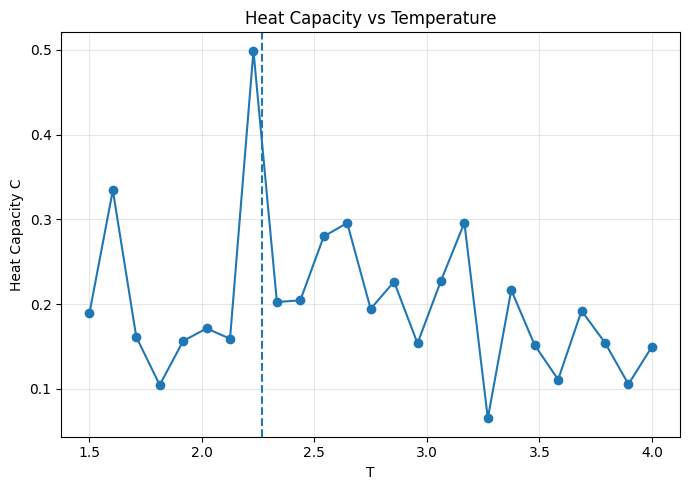

In [40]:
plt.figure(figsize=(7,5))
plt.plot(T_vals, C_vs_T, 'o-')
plt.axvline(2.269, linestyle="--")
plt.xlabel("T")
plt.ylabel("Heat Capacity C")
plt.title("Heat Capacity vs Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

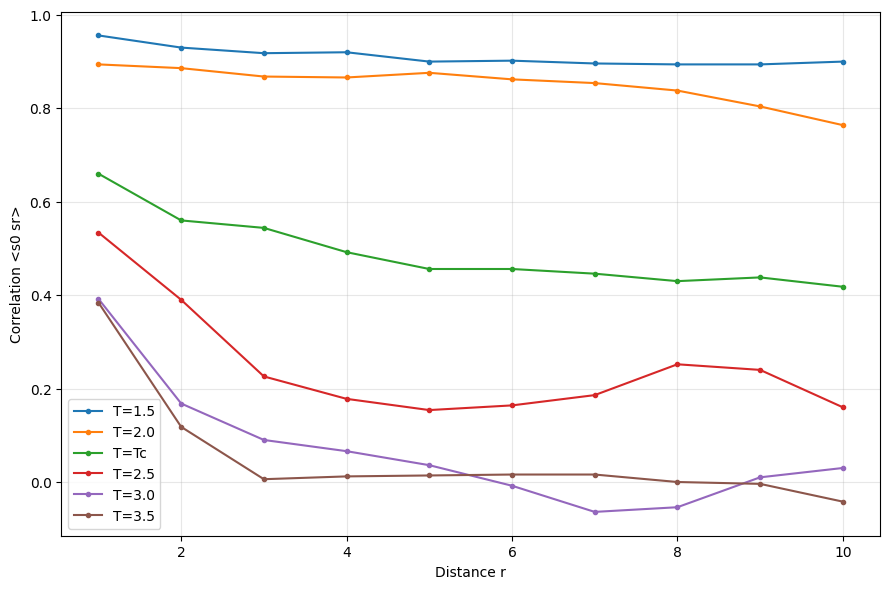

In [43]:
plt.figure(figsize=(9,6))

for T in T_corr:
    d, f = correlation_data[T]
    label = "T=Tc" if abs(T-2.269)<1e-3 else f"T={T}"
    plt.plot(d, f, 'o-', markersize=3, label=label)

plt.xlabel("Distance r")
plt.ylabel("Correlation <s0 sr>")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()